<a href="https://colab.research.google.com/github/fahrabyf200/PVCK_Ganjil_2025/blob/main/week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil di-mount.
ERROR: Gagal memuat citra dari path: /content/drive/MyDrive/Images/gradient.jpg.
Menggunakan citra gradient artifisial sebagai gantinya.


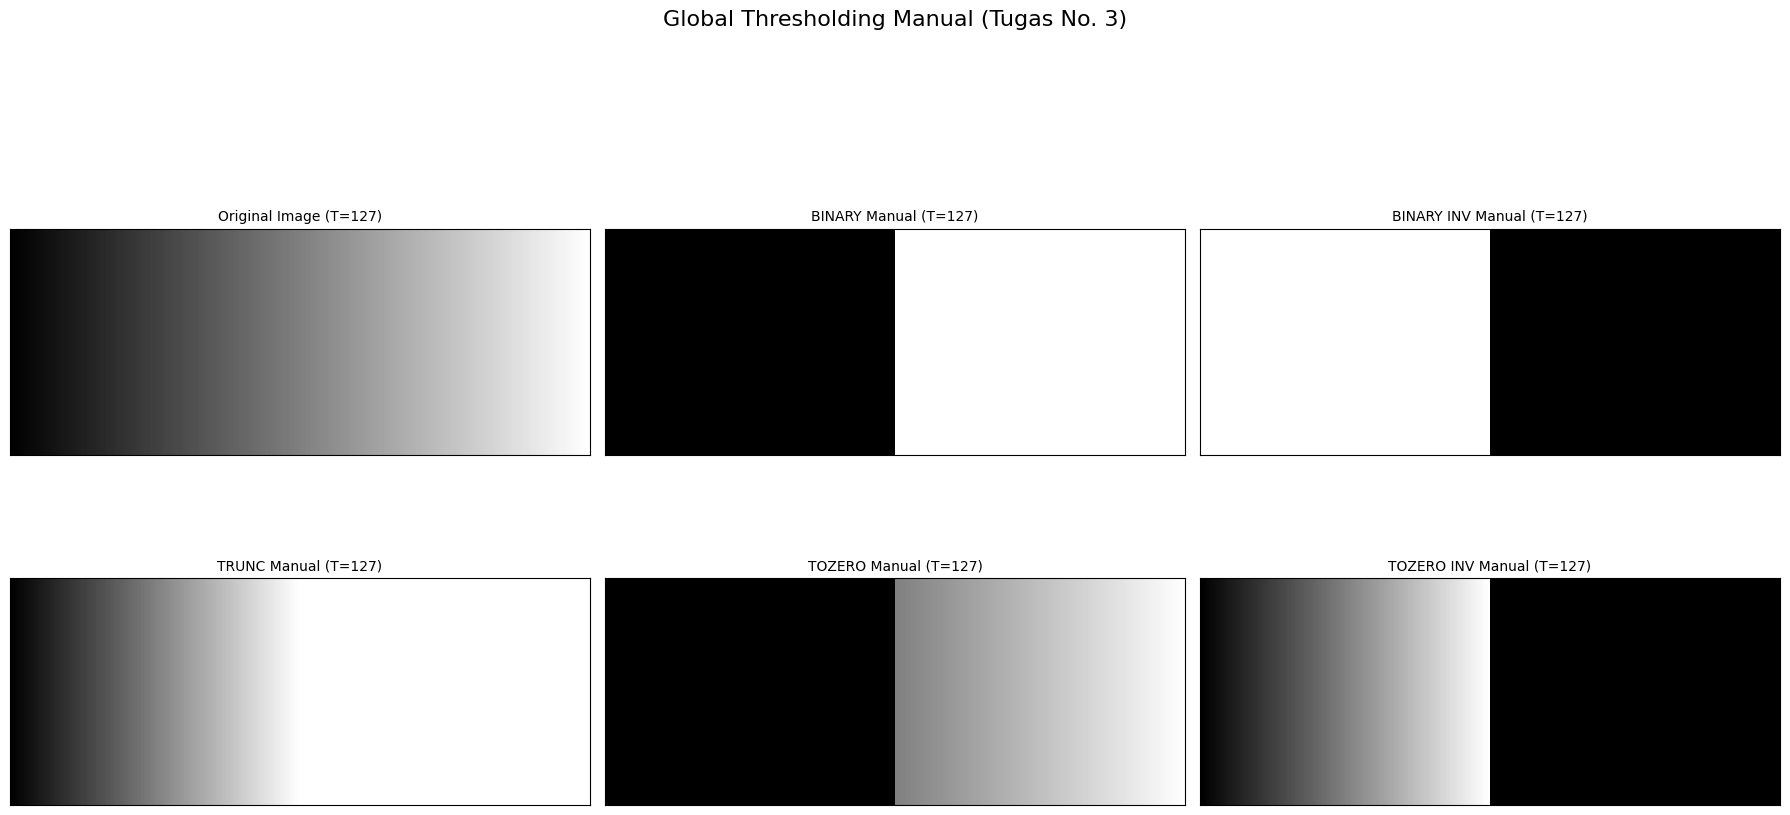

In [ ]:

import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
# import cv2_imshow # Tidak digunakan jika plotting dengan Matplotlib

# ==============================================================================
# 0. MOUNT GOOGLE DRIVE (Penting untuk Colab)
# ==============================================================================
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive berhasil di-mount.")
except Exception as e:
    print(f"Gagal me-mount Drive: {e}. Pastikan Anda menjalankannya di Colab.")

# ==============================================================================
# 1. PERSIAPAN DATA DAN PENGATURAN AWAL
# ==============================================================================

# **PATH GAMBAR DARI PENGGUNA**
# Path yang benar sesuai struktur Colab/Drive
filename = '/content/drive/MyDrive/Images/gradient.jpg'

thresh = 127 # Nilai Threshold
maxval = 255

# Muat Citra sebagai Grayscale (argumen 0) dan pastikan data type-nya
img = cv.imread(filename, 0)

if img is None:
    print(f"ERROR: Gagal memuat citra dari path: {filename}.")
    print("Menggunakan citra gradient artifisial sebagai gantinya.")
    img = np.array([np.arange(0, 256)], dtype=np.uint8)
    img = np.repeat(img, 100, axis=0) # Fallback

# Salin dan pastikan tipe data adalah np.uint8 (penting untuk operasi citra 0-255)
src = img.astype(np.uint8)

# ==============================================================================
# 2. IMPLEMENTASI GLOBAL THRESHOLDING SECARA MANUAL
# ==============================================================================

# a. BINARY THRESHOLD MANUAL
# dst = maxval jika src > thresh, 0 jika lainnya
dst_binary = np.zeros_like(src, dtype=np.uint8)
dst_binary[src > thresh] = maxval

# b. BINARY-INVERTED THRESHOLD MANUAL
# dst = 0 jika src > thresh, maxVal jika lainnya
dst_binary_inv = np.zeros_like(src, dtype=np.uint8)
dst_binary_inv[src <= thresh] = maxval

# c. TRUNCATE THRESHOLD MANUAL (Bagian yang Dicurigai)
# Rumus: dst = thresh jika src > thresh, src jika lainnya
dst_trunc = src.copy()
# Semua piksel yang nilainya lebih besar dari 127, DIPAKSA menjadi 127
dst_trunc[src > thresh] = thresh
# Jika hasil Anda masih terlihat bergradasi di sisi kanan, kemungkinan citra 'gradient.jpg'
# Anda mungkin memiliki nilai piksel yang hanya sedikit di atas 127 atau pembagiannya tidak tepat.
# Namun, logika ini secara matematis benar sesuai rumus modul.

# d. THRESHOLD TO ZERO MANUAL
# Rumus: dst = src jika src > thresh, 0 jika lainnya
dst_to_zero = src.copy()
dst_to_zero[src <= thresh] = 0

# e. THRESHOLD TO ZERO - INVERTED MANUAL
# Rumus: dst = 0 jika src > thresh, src jika lainnya
dst_to_zero_inv = src.copy()
dst_to_zero_inv[src > thresh] = 0


# ==============================================================================
# 3. MENAMPILKAN HASIL
# ==============================================================================

titles = ['Original Image', 'BINARY Manual', 'BINARY INV Manual',
          'TRUNC Manual', 'TOZERO Manual', 'TOZERO INV Manual']

images = [src, dst_binary, dst_binary_inv, dst_trunc, dst_to_zero, dst_to_zero_inv]

plt.figure(figsize=(18, 10))
for i in range(len(images)):
    # Gunakan 'gray' cmap dan interpolasi 'nearest' untuk hasil biner yang tajam
    plt.subplot(2, 3, i + 1), plt.imshow(images[i], 'gray', interpolation='nearest')
    plt.title(f"{titles[i]} (T={thresh})", fontsize=10)
    plt.xticks([]), plt.yticks([])

plt.suptitle("Global Thresholding Manual (Tugas No. 3)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


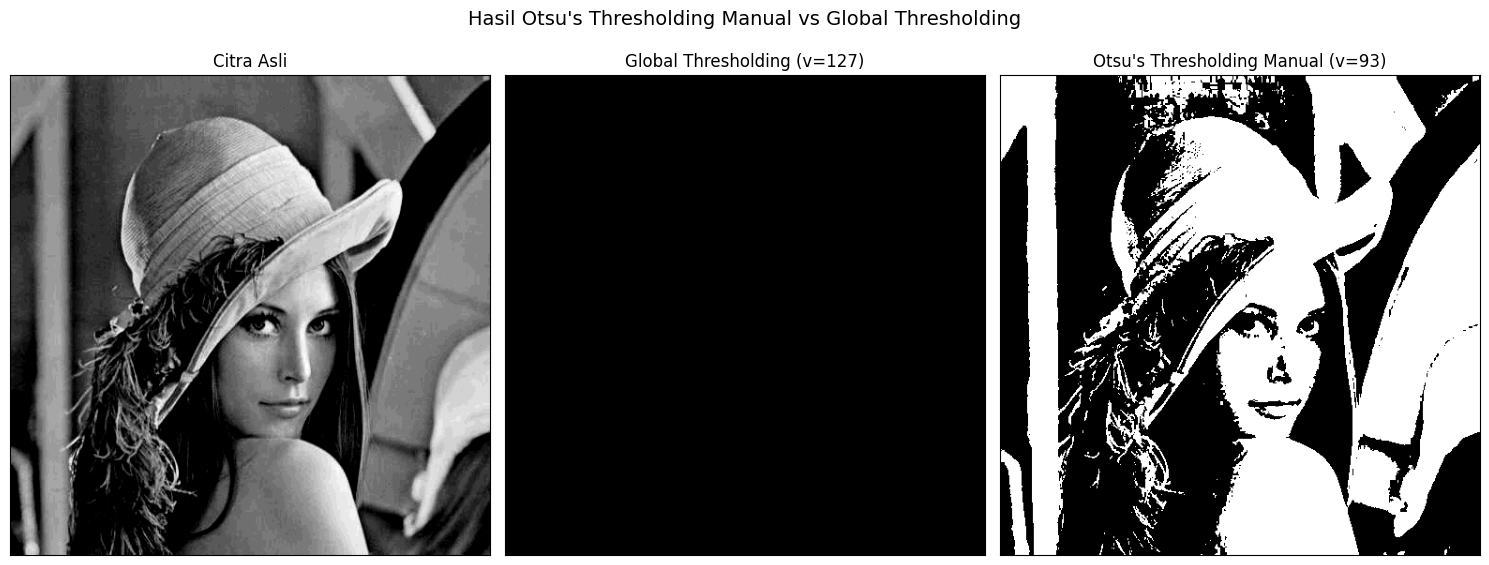


Nilai Threshold Otsu's (Manual) yang ditemukan: T = 93
Nilai Threshold Otsu's (OpenCV) untuk verifikasi: T = 92.0


In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

# ==============================================================================
# 0. MOUNT GOOGLE DRIVE & PEMUATAN GAMBAR
# ==============================================================================
try:
    drive.mount('/content/drive')
except:
    pass # Asumsi sudah di-mount

# **PATH GAMBAR DARI PENGGUNA**
filename_lena = '/content/drive/MyDrive/lena_gs_lc2.jpg'
img_lena = cv.imread(filename_lena, 0) # Muat sebagai grayscale

if img_lena is None:
    print(f"ERROR: Gagal memuat citra dari path: {filename_lena}. Menggunakan citra dummy.")
    # Fallback jika gagal muat
    img_lena = np.zeros((100, 100), dtype=np.uint8)

src = img_lena.copy()

# ==============================================================================
# 1. FUNGSI OTSU'S MANUAL
# ==============================================================================

def otsu_manual(image):
    # 1. Hitung Histogram
    histogram, bin_edges = np.histogram(image, bins=256, range=(0, 256))

    # Normalisasi histogram untuk mendapatkan probabilitas (p(i))
    total_pixels = image.size
    probabilities = histogram / total_pixels

    # Inisialisasi variabel untuk melacak ambang batas terbaik
    best_threshold = 0
    max_between_variance = 0.0

    # 2. Iterasi untuk semua kemungkinan ambang batas t (dari 1 hingga 255)
    for t in range(1, 256):

        # --- BACKGROUND (Kelas 0: 0 hingga t-1) ---
        # Weight Background (omega_0)
        omega0 = np.sum(probabilities[:t])

        # Mean Background (mu_0)
        mu0 = np.sum(np.arange(t) * probabilities[:t]) / omega0 if omega0 > 0 else 0

        # --- FOREGROUND (Kelas 1: t hingga 255) ---
        # Weight Foreground (omega_1)
        omega1 = np.sum(probabilities[t:])

        # Mean Foreground (mu_1)
        # Note: np.arange(t, 256) mengacu pada bin t hingga 255
        mu1 = np.sum(np.arange(t, 256) * probabilities[t:]) / omega1 if omega1 > 0 else 0

        # --- HITUNG BETWEEN CLASS VARIANCE (sigma_B^2) ---
        # Rumus: sigma_B^2 = omega0 * omega1 * (mu0 - mu1)^2
        between_variance = omega0 * omega1 * (mu0 - mu1)**2

        # 3. Cari T yang memaksimalkan between_variance
        if between_variance > max_between_variance:
            max_between_variance = between_variance
            best_threshold = t

    return best_threshold

# Jalankan Otsu's manual
optimal_T = otsu_manual(src)

# Terapkan Global Thresholding biasa (T=127) untuk perbandingan
ret1, th_global = cv.threshold(src, 127, 255, cv.THRESH_BINARY)

# Terapkan Binary Threshold menggunakan T hasil Otsu manual
ret_otsu_manual, th_otsu_manual = cv.threshold(src, optimal_T, 255, cv.THRESH_BINARY)


# ==============================================================================
# 2. MENAMPILKAN HASIL
# ==============================================================================

titles = ['Citra Asli',
          f'Global Thresholding (v=127)',
          f"Otsu's Thresholding Manual (v={optimal_T})"]

images = [src, th_global, th_otsu_manual]

plt.figure(figsize=(15, 6))

for i in range(len(images)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i], fontsize=12)
    plt.xticks([]), plt.yticks([])

plt.suptitle(f"Hasil Otsu's Thresholding Manual vs Global Thresholding", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nNilai Threshold Otsu's (Manual) yang ditemukan: T = {optimal_T}")

# Cek dengan fungsi Otsu bawaan OpenCV (opsional, untuk verifikasi)
ret2_cv, th_cv = cv.threshold(src, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
print(f"Nilai Threshold Otsu's (OpenCV) untuk verifikasi: T = {ret2_cv}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


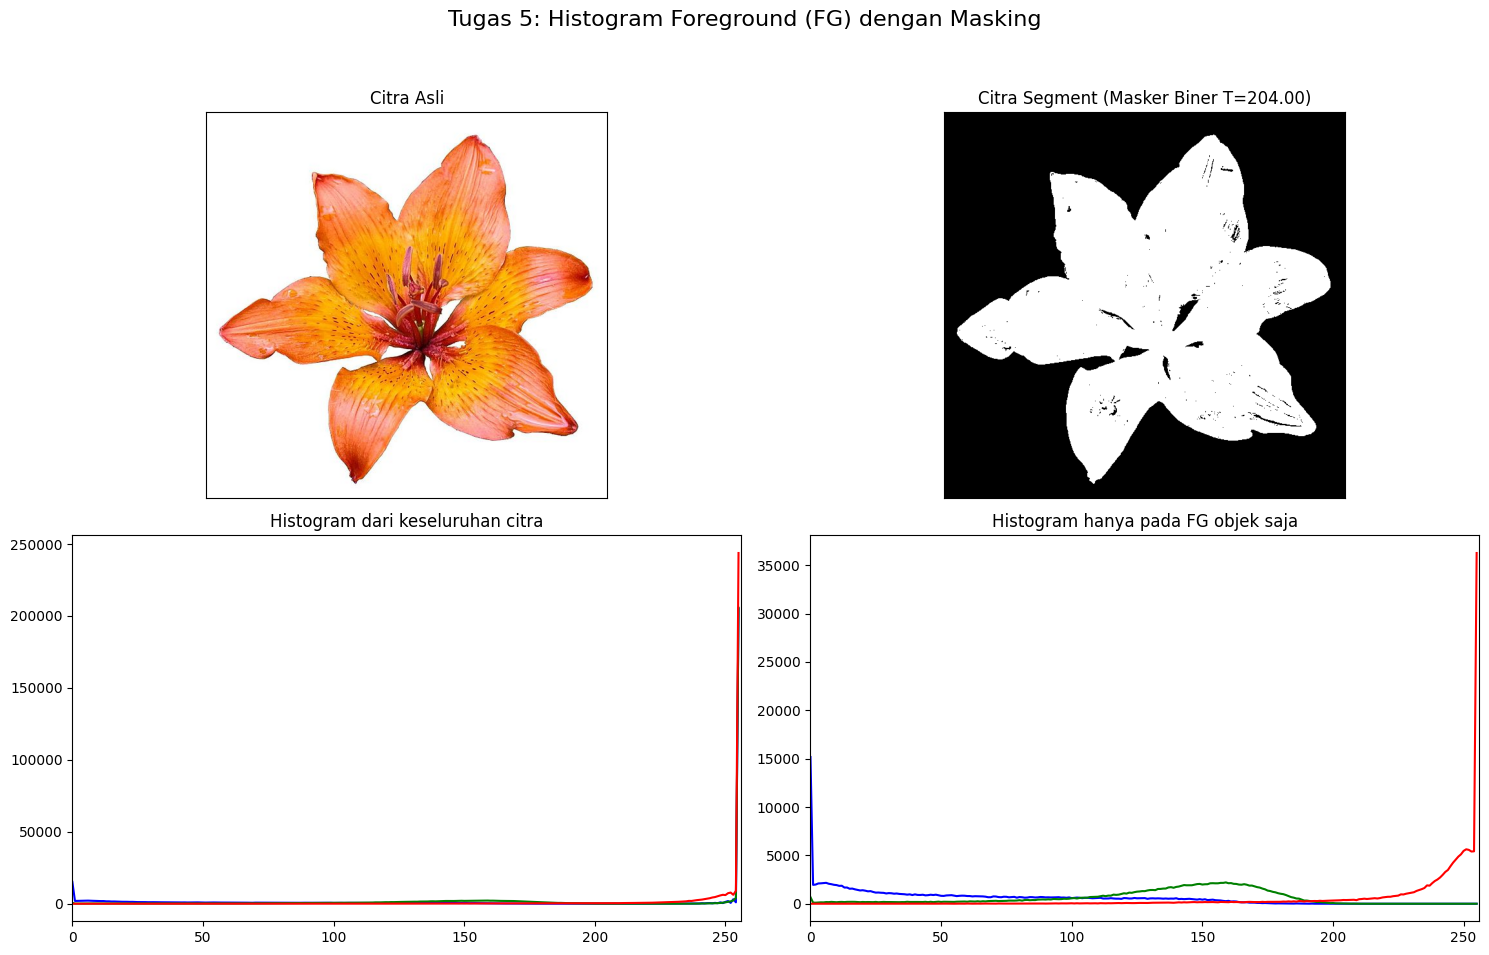


Nilai Threshold Otsu's yang digunakan untuk masker: T = 204.00


In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

# ==============================================================================
# 0. MOUNT GOOGLE DRIVE & PEMUATAN GAMBAR
# ==============================================================================
try:
    drive.mount('/content/drive')
except:
    pass

# **PATH GAMBAR DARI PENGGUNA**
filename_lily = '/content/drive/MyDrive/lily.jpg'

# Muat Citra Berwarna (argumen 1)
img_color = cv.imread(filename_lily, 1)

if img_color is None:
    print(f"ERROR: Gagal memuat citra dari path: {filename_lily}. Menggunakan citra dummy.")
    # Fallback jika gagal muat
    img_color = np.zeros((200, 200, 3), dtype=np.uint8)

# Konversi ke RGB untuk tampilan Matplotlib
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

# Konversi ke Grayscale untuk Thresholding Masker
img_gray = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)


# ==============================================================================
# 1. SEGMENTASI/THRESHOLDING (Membuat Masker)
# ==============================================================================

# Gunakan Otsu's Thresholding untuk segmentasi otomatis
# Ini akan menghasilkan masker biner terbaik (Putih = Foreground, Hitam = Background)
ret, mask_lily = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
# Nilai 'ret' adalah nilai threshold Otsu's yang ditemukan

# Karena Otsu's mungkin menganggap bunga sebagai background (lebih gelap dari latar putih),
# kita mungkin perlu melakukan inverse jika hasilnya terbalik
# Biasanya pada latar belakang putih: Bunga (gelap) -> 0, Background (putih) -> 255.
# Kita ingin BUNGA menjadi PUTIH (255) pada masker.
# Jika hasilnya terbalik, lakukan BINARY_INV
if ret > 150: # Ambang batas tinggi menandakan latar belakang cenderung terang
     ret, mask_lily = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# Pastikan masker bunga berwarna putih (255)
# Anda mungkin perlu menyesuaikan/mengecek visual masker jika mask_lily tidak terbalik:
# Jika bunga hitam dan latar putih: ret, mask_lily = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

# ==============================================================================
# 2. PERHITUNGAN HISTOGRAM (Keseluruhan dan Masked)
# ==============================================================================

color = ('b','g','r')
titles = ['Histogram dari keseluruhan citra', 'Histogram hanya pada FG objek saja']

plt.figure(figsize=(15, 10))

# --- HISTOGRAM KESELURUHAN CITRA ---
plt.subplot(2, 2, 3)
for i, col in enumerate(color):
    # Hitung histogram untuk keseluruhan citra (mask = None)
    hist_full = cv.calcHist([img_color], [i], None, [256], [0, 256])
    plt.plot(hist_full, color=col)
    plt.xlim([0, 256])
plt.title(titles[0])


# --- HISTOGRAM HANYA OBJEK FG (Menggunakan Masker) ---
plt.subplot(2, 2, 4)
for i, col in enumerate(color):
    # Hitung histogram hanya pada area mask_lily (area putih pada masker)
    hist_mask = cv.calcHist([img_color], [i], mask_lily, [256], [0, 256])
    plt.plot(hist_mask, color=col)
    plt.xlim([0, 256])
plt.title(titles[1])


# --- TAMPILAN CITRA ---
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.xticks([]), plt.yticks([])

plt.subplot(2, 2, 2)
# Konversi masker (grayscale) menjadi citra 3-channel untuk ditampilkan dengan imshow Matplotlib
plt.imshow(cv.cvtColor(mask_lily, cv.COLOR_GRAY2RGB))
plt.title(f'Citra Segment (Masker Biner T={ret:.2f})')
plt.xticks([]), plt.yticks([])

plt.suptitle("Tugas 5: Histogram Foreground (FG) dengan Masking", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\nNilai Threshold Otsu's yang digunakan untuk masker: T = {ret:.2f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Centroid Warna yang Ditemukan:
[[252 250 248]
 [143  42  19]
 [176 131  82]
 [250 206   4]]

Cluster yang diidentifikasi sebagai Kuning: Cluster 3
Warna Centroid Kuning: [250 206   4]


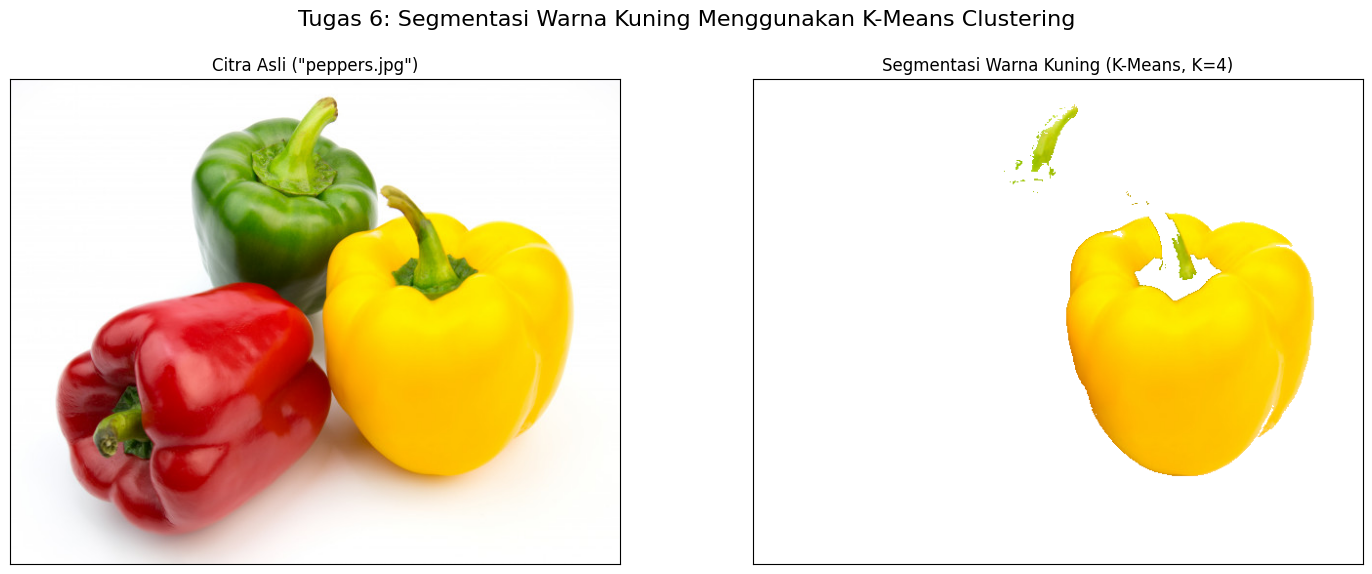

PROBLEMS ENCOUNTERED (MASALAH YANG DIHADAPI):
1. **Cluster Identification:** Automatically or manually determining which cluster *definitely* represents yellow is challenging, as yellow, orange-yellow, and highlights may merge into one cluster if K is small.
2. **Inclusion of Other Colors:** Bright white highlights on the yellow pepper (visually part of the object) are often incorrectly grouped with the pure white background cluster.

CAUSES (PENYEBABNYA):
1. **Overlapping RGB Values:** The bright yellow/white highlights on the pepper are very close to the pure white background color space (e.g., [255, 255, X] vs [255, 255, 255]). K-Means groups based purely on proximity in the RGB space, leading to misclassification.
2. **K-Value Selection:** If K is too small (Under-Segmentation), the 'Yellow' cluster might contain unwanted colors (Red/Green).
3. **K-Means Dependency on Initialization:** Due to random starting centers, the specific cluster ID corresponding to 'yellow' can vary across

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

# ==============================================================================
# 0. MOUNT GOOGLE DRIVE & PEMUATAN GAMBAR
# ==============================================================================
try:
    drive.mount('/content/drive')
except:
    pass

# **PATH GAMBAR**
filename_peppers = '/content/drive/MyDrive/peppers.jpg'

# Muat Citra Berwarna (argumen 1)
img = cv.imread(filename_peppers, 1)

if img is None:
    print(f"ERROR: Gagal memuat citra dari path: {filename_peppers}. Menggunakan citra dummy.")
    img = np.zeros((300, 300, 3), dtype=np.uint8)

# Konversi BGR ke RGB untuk Matplotlib
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_h, img_w, _ = img_rgb.shape

# ==============================================================================
# 1. PERSIAPAN DATA UNTUK K-MEANS
# ==============================================================================

# Reshape citra 3D menjadi 2D (jumlah_piksel x 3) [cite: 460]
pixel_values = img_rgb.reshape((-1, 3))
# Konversi ke float32 (persyaratan cv.kmeans) [cite: 462]
pixel_values = np.float32(pixel_values)

# ==============================================================================
# 2. KONFIGURASI K-MEANS
# ==============================================================================

# Jumlah cluster (K)
K = 4 # Diperkirakan ada 4 warna utama: Merah, Hijau, Kuning, Latar Putih

# Kriteria penghentian iterasi [cite: 467]
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# ==============================================================================
# 3. MENJALANKAN K-MEANS
# ==============================================================================
ret, labels, centers = cv.kmeans(
    pixel_values,
    K,
    None,
    criteria,
    10,
    cv.KMEANS_RANDOM_CENTERS
)

# Konversi centers (centroid) ke integer uint8 (nilai warna) [cite: 475]
centers = np.uint8(centers)
# Flattening label array [cite: 477]
labels = labels.flatten()

# ==============================================================================
# 4. MASKING UNTUK WARNA KUNING
# ==============================================================================

# 4a. Identifikasi Cluster Kuning
# Centroid adalah representasi warna rata-rata dari setiap cluster.
# Kita perlu mencari cluster mana yang paling menyerupai warna KUNING (R tinggi, G tinggi, B rendah).
print("Centroid Warna yang Ditemukan:")
print(centers)

# Asumsikan warna kuning memiliki nilai R dan G yang tinggi.
# Secara visual, cluster kuning biasanya memiliki nilai R & G yang paling berimbang/tinggi.
# Kita akan mencari cluster dengan nilai R yang tinggi dan nilai B yang relatif rendah.
# Pilihan terbaik adalah cluster yang memiliki R+G tertinggi dan B terendah.

# Kita akan tentukan secara visual/manual setelah melihat centernya,
# tapi sebagai heuristik awal:
# Cek cluster yang memiliki nilai R > 150 dan G > 150, dan B < 100 (Kuning cerah)
cluster_kuning = -1
for i in range(K):
    R, G, B = centers[i]
    if R > 150 and G > 150 and B < 100:
        cluster_kuning = i
        break

# Jika heuristik gagal, asumsikan secara default cluster yang memiliki R dan G tertinggi
if cluster_kuning == -1:
    print("Heuristik gagal menemukan cluster kuning cerah. Mencari cluster R+G tertinggi...")
    sums = centers[:, 0] + centers[:, 1]
    cluster_kuning = np.argmax(sums)


print(f"\nCluster yang diidentifikasi sebagai Kuning: Cluster {cluster_kuning}")
print(f"Warna Centroid Kuning: {centers[cluster_kuning]}")


# 4b. Membuat Masker Biner
# Buat citra segmentasi di mana hanya cluster_kuning yang dipertahankan
masked_image = np.zeros_like(img_rgb, dtype=np.uint8)
# Dapatkan indeks piksel yang termasuk dalam cluster kuning
mask_indices = (labels == cluster_kuning)
# Tetapkan nilai warna asli pada piksel di cluster kuning
masked_image.reshape((-1, 3))[mask_indices] = pixel_values.reshape((-1, 3))[mask_indices].astype(np.uint8)

# Opsional: Untuk membuat latar belakang Putih (seperti contoh modul)
# Kita bisa membuat background menjadi putih (255, 255, 255) alih-alih hitam (0, 0, 0)
masked_image_white_bg = np.full_like(img_rgb, 255, dtype=np.uint8)
masked_image_white_bg.reshape((-1, 3))[mask_indices] = pixel_values.reshape((-1, 3))[mask_indices].astype(np.uint8)


# ==============================================================================
# 5. MENAMPILKAN HASIL
# ==============================================================================

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli ("peppers.jpg")')
plt.xticks([]), plt.yticks([])

plt.subplot(1, 2, 2)
plt.imshow(masked_image_white_bg)
plt.title(f'Segmentasi Warna Kuning (K-Means, K={K})')
plt.xticks([]), plt.yticks([])

plt.suptitle("Tugas 6: Segmentasi Warna Kuning Menggunakan K-Means Clustering", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ==============================================================================
# 6. JAWABAN PERTANYAAN: MASALAH & PENYEBABNYA
# ==============================================================================
print("PROBLEMS ENCOUNTERED (MASALAH YANG DIHADAPI):")
print("1. **Cluster Identification:** Automatically or manually determining which cluster *definitely* represents yellow is challenging, as yellow, orange-yellow, and highlights may merge into one cluster if K is small.")
print("2. **Inclusion of Other Colors:** Bright white highlights on the yellow pepper (visually part of the object) are often incorrectly grouped with the pure white background cluster.")

print("\nCAUSES (PENYEBABNYA):")
print("1. **Overlapping RGB Values:** The bright yellow/white highlights on the pepper are very close to the pure white background color space (e.g., [255, 255, X] vs [255, 255, 255]). K-Means groups based purely on proximity in the RGB space, leading to misclassification.")
print("2. **K-Value Selection:** If K is too small (Under-Segmentation), the 'Yellow' cluster might contain unwanted colors (Red/Green).")
print("3. **K-Means Dependency on Initialization:** Due to random starting centers, the specific cluster ID corresponding to 'yellow' can vary across different runs.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


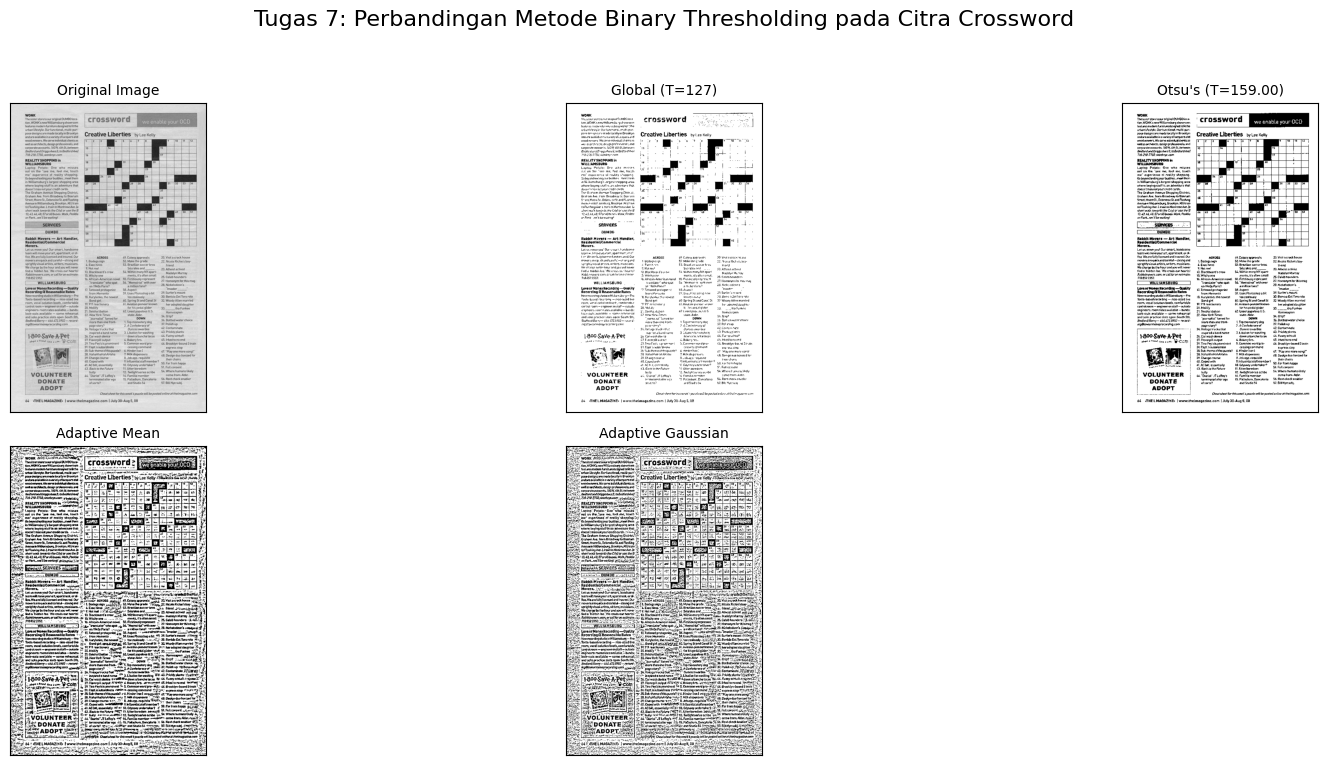

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

# ==============================================================================
# 0. MOUNT GOOGLE DRIVE & PEMUATAN GAMBAR
# ==============================================================================
try:
    drive.mount('/content/drive')
except:
    pass

# **PATH GAMBAR**
filename_crossword = '/content/drive/MyDrive/crossword.jpg'

# Muat Citra sebagai Grayscale
img = cv.imread(filename_crossword, 0)

if img is None:
    print(f"ERROR: Gagal memuat citra dari path: {filename_crossword}.")
    # Fallback ke dummy image jika gagal muat
    img = np.zeros((300, 300), dtype=np.uint8)

src = img.copy()

# ==============================================================================
# 2. PERBANDINGAN TIGA METODE THRESHOLDING
# ==============================================================================

# 1. GLOBAL THRESHOLDING (Nilai T tetap = 127)
ret1, th1 = cv.threshold(src, 127, 255, cv.THRESH_BINARY)
# Hasil ini biasanya buruk pada citra dengan pencahayaan tidak merata.

# 2. OTSU'S THRESHOLDING
# Otsu's secara otomatis menghitung T terbaik, tetapi T ini tetap tunggal (Global).
# Kita menggunakan cv.THRESH_BINARY + cv.THRESH_OTSU
ret2, th2 = cv.threshold(src, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# 3. ADAPTIVE MEAN THRESHOLDING
# Nilai T dihitung sebagai rata-rata area tetangga (Block Size).
# Block Size = 11, C = 2 (Konstanta yang dikurangi dari rata-rata/mean) [cite: 131, 132]
th3 = cv.adaptiveThreshold(
    src,
    255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY,
    11, # Block Size
    2   # C
)

# 4. ADAPTIVE GAUSSIAN THRESHOLDING
# Nilai T dihitung sebagai rata-rata tertimbang Gaussian area tetangga.
th4 = cv.adaptiveThreshold(
    src,
    255,
    cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv.THRESH_BINARY,
    11, # Block Size
    2   # C
)

# ==============================================================================
# 3. MENAMPILKAN HASIL DAN MENENTUKAN YANG TERBAIK
# ==============================================================================

titles = [
    'Original Image',
    'Global (T=127)',
    f"Otsu's (T={ret2:.2f})",
    'Adaptive Mean',
    'Adaptive Gaussian'
]
images = [src, th1, th2, th3, th4]

plt.figure(figsize=(18, 8))

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    # Gunakan 'gray' cmap
    plt.imshow(images[i], 'gray')
    plt.title(titles[i], fontsize=10)
    plt.xticks([]), plt.yticks([])

plt.suptitle("Tugas 7: Perbandingan Metode Binary Thresholding pada Citra Crossword", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()